# Customer Purchase Behavior Analysis using Descriptive Statistics

##Problem Statement

🔍 **Problem Statement**:

Welcome to the Probability and Statistics project! 📊🔍 In this exciting journey, you'll get the chance to apply the concepts you've learned in probability theory and statistics to analyze a real-world dataset. This project is your opportunity to dive deep into the world of data analysis and gain practical experience with the tools and techniques you've been learning. 🚀

🎯 **Objective**:

Your mission is to analyze the provided dataset containing customer information and purchasing behavior to make informed decisions. Your goal is to identify patterns, trends, and correlations that will help your company optimize its marketing efforts and increase offer acceptance rates. 🎉

##About the Dataset



Here's the link to the [dataset](https://docs.google.com/spreadsheets/d/12ln9iTNcVNOMYi_AU-OczKpa_KIP8XyVbsjk81Na8Yk/edit?usp=sharing)


This data was gathered during last year's campaign.
Data description is as follows;

1. Response (target) - 1 if customer accepted the offer in the last campaign, 0 otherwise
1. ID - Unique ID of each customer
1. Year_Birth - Age of the customer
1. Complain - 1 if the customer complained in the last 2 years
1. Dt_Customer - date of customer's enrollment with the company
1. Education - customer's level of education
1. Marital - customer's marital status
1. Kidhome - number of small children in customer's household
1. Teenhome - number of teenagers in customer's household
1. Income - customer's yearly household income
1. MntFishProducts - the amount spent on fish products in the last 2 years
1. MntMeatProducts - the amount spent on meat products in the last 2 years
1. MntFruits - the amount spent on fruits products in the last 2 years
1. MntSweetProducts - amount spent on sweet products in the last 2 years
1. MntWines - the amount spent on wine products in the last 2 years
1. MntGoldProds - the amount spent on gold products in the last 2 years
1. NumDealsPurchases - number of purchases made with discount
1. NumCatalogPurchases - number of purchases made using catalog (buying goods to be shipped through the mail)
1. NumStorePurchases - number of purchases made directly in stores
1. NumWebPurchases - number of purchases made through the company's website
1. NumWebVisitsMonth - number of visits to company's website in the last month
1. Recency - number of days since the last purchase





In [ ]:
#Library used
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Applied Statistics/Superstore Marketing Data.xlsx")
OUT_DIR= "/content/drive/MyDrive/Colab Notebooks/Applied Statistics/outputs"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Task 1 - Basic CleanUp

- **Clean and preprocess the dataset (handling missing values, data types, etc.).**

- **Analyze the distribution of customer demographics (age, education, marital status) using descriptive statistics and visualizations.**



**Deliverables**:

- **Cleaned and Preprocessed Dataset**:

  Provide a detailed report on the steps taken to handle missing values, including imputation methods used if applicable.
  Document the process of ensuring consistent data types for each variable, addressing any inconsistencies.

- **Summary of Basic Statistics**:

  Present calculated statistics such as mean, median, variance, and standard deviation for each relevant numerical variable.
  Include a concise table or summary showcasing these measures for easy reference.

In [ ]:
# Basic referance
Reference_year= 2014  #latest enrolment date is in 2014
Max_age= 114         # age above this treated as invalid(born before 1900, it rare to have some above 114 years)
Extreme_IQR_K = 3.0  #"extreme oultier" fence for income : Q3+ 3*IQR
os.makedirs(OUT_DIR, exist_ok=True)
sns.set_theme(style="whitegrid")

In [ ]:
df= df.rename(columns={"Id": "ID"})
print("Original shape:", df.shape)
print(df.dtypes, "\n")
print("Missing values:\n", df.isna().sum()[df.isna().sum()>0],"\n")
print("Duplicate rows:", df.duplicated().sum(), "| duplicate IDs:", df["ID"].duplicated().sum())


Original shape: (2240, 22)
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
Response                 int64
Complain                 int64
dtype: object 

Missing values:
 Income    24
dtype: int64 

Duplicate rows: 0 | duplicate IDs: 0


In [ ]:
#Handling the data types isuue

#Convertinig the DT_Customer data type to Date in format of mm/dd/yyy, converted the value to NaT that are not real Date, print error count for that
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%m/%d/%Y", errors="coerce")
print("Unreadable / missing enrolment dates:", df["Dt_Customer"].isna().sum(),"\n")

#Tidy categories (Alone, Yolo , Absurd are not meaningful martial statuses)
print(df['Marital_Status'].value_counts(),"\n")
df['Marital_Status'] = df['Marital_Status'].replace(['Alone', 'YOLO', 'Absurd'], 'Single')
print(df['Marital_Status'].value_counts())



Unreadable / missing enrolment dates: 916 

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64 

Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64


In [ ]:
# Derived Columns
df['Age'] = Reference_year - df['Year_Birth']
print(df['Age'].describe(),"\n")

#------------------------------------------------------------------------------------------------
#Total Spend and total purchase count
mnt_cols = ['MntFishProducts', 'MntMeatProducts', 'MntFruits', 'MntSweetProducts', 'MntWines', 'MntGoldProds']
df["Total_Spend"] = df[mnt_cols].sum(axis=1)
df["Total_Purchase"] = df[["NumCatalogPurchases", "NumStorePurchases", "NumWebPurchases"]].sum(axis=1)
#I left NumDealsPurchases because NumDealsPurchases is probably not a separate kind of purchase.
#The three channel columns say where the customer bought: on the website, through the catalog, or in a store.
#A discounted purchase still happened through one of those three channels, so it would be counted twice if I added it.
#----------------------------------------------------------------------------------------------

#Total Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]
#----------------------------------------------------------------------------------------------
#How many days each customer has been enrolled with the company, counted up to a fixed end date (31 December 2014)
df["Tenure_Days"] = (pd.Timestamp(f"{Reference_year}-12-31") - df["Dt_Customer"]).dt.days

count    2240.000000
mean       45.194196
std        11.984069
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max       121.000000
Name: Age, dtype: float64 



In [ ]:
#Outlier Detection
def iqr_fences(s, k=1.5):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

#find the outlier for the each column
num_cols = ['Income', 'Age','Recency','Kidhome','Teenhome'] + mnt_cols + ["Total_Spend", "Total_Purchase", "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth"]
report= []
for c in num_cols:
  Low, High = iqr_fences(df[c].dropna())
  n_out = ((df[c]<Low)| (df[c]> High)).sum()
  report.append([c,round(Low,1), round(High,1), int(n_out)])

outlier_report= pd.DataFrame(report, columns=["Variable", "Lower Fence", "Upper Fence", "IQR Outlliers"])
print(outlier_report.to_string(index=False),"\n")



           Variable  Lower Fence  Upper Fence  IQR Outlliers
             Income     -14525.5     118350.5              8
                Age         10.0         82.0              3
            Recency        -51.0        149.0              0
            Kidhome         -1.5          2.5              0
           Teenhome         -1.5          2.5              0
    MntFishProducts        -67.5        120.5            223
    MntMeatProducts       -308.0        556.0            175
          MntFruits        -47.0         81.0            227
   MntSweetProducts        -47.0         81.0            248
           MntWines       -697.0       1225.0             35
       MntGoldProds        -61.5        126.5            207
        Total_Spend      -1396.4       2510.6              3
     Total_Purchase        -12.0         36.0              0
  NumDealsPurchases         -2.0          6.0             86
    NumWebPurchases         -4.0         12.0              4
NumCatalogPurchases     

In [ ]:
#Find the Invalid records with explicits rules and print them before removing
invalid_age= df[df["Age"]>Max_age]
print("Invalid ages(Age> %d):"%Max_age)
print(invalid_age[["ID", "Year_Birth", "Age"]].to_string(index=False),"\n")

#Extreme Income
_, inc_hi = iqr_fences(df["Income"].dropna(), k=Extreme_IQR_K)
extreme_income = df[df["Income"] > inc_hi]
print("Extreme income outliers (> Q3 + %.0f*IQR = %.0f):" % (Extreme_IQR_K, inc_hi))
print(extreme_income[["ID", "Income"]].to_string(index=False), "\n")


Invalid ages(Age> 114):
   ID  Year_Birth  Age
11004        1893  121
 1150        1899  115 

Extreme income outliers (> Q3 + 3*IQR = 168179):
  ID   Income
9432 666666.0 



In [ ]:
#Remove the etreme values
to_drop = invalid_age.index.union(extreme_income.index)
df= df.drop(index=to_drop).reset_index(drop=True)
print("Rows Removed:", len(to_drop), "| rows left:", len(df))


Rows Removed: 3 | rows left: 2237


In [ ]:
#Missing Income : Impute with the median of the customer's Education group
print("Missing income before imputation:", df["Income"].isna().sum())
df["Income_Imputed"]= df["Income"].isna().astype(int)
df["Income"] =df.groupby("Education")["Income"].transform(lambda x: x.fillna(x.median()))
print("Missing income after imputation:", df["Income"].isna().sum())



Missing income before imputation: 24
Missing income after imputation: 0


In [ ]:
#Storing the claen data to new excel
df.to_csv(os.path.join(OUT_DIR, "Cleaned_Superstore_Marketing_Data.csv"), index=False)
print("Final Data:", df.shape)
df.info()

Final Data: (2237, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2237 non-null   int64         
 1   Year_Birth           2237 non-null   int64         
 2   Education            2237 non-null   object        
 3   Marital_Status       2237 non-null   object        
 4   Income               2237 non-null   float64       
 5   Kidhome              2237 non-null   int64         
 6   Teenhome             2237 non-null   int64         
 7   Dt_Customer          1322 non-null   datetime64[ns]
 8   Recency              2237 non-null   int64         
 9   MntWines             2237 non-null   int64         
 10  MntFruits            2237 non-null   int64         
 11  MntMeatProducts      2237 non-null   int64         
 12  MntFishProducts      2237 non-null   int64         
 13  MntSweetPr

count    2237.00
mean       45.13
std        11.79
min        18.00
25%        37.00
50%        44.00
75%        55.00
max       114.00
Name: Age, dtype: float64 

Education
Graduation    50.3%
PhD           21.7%
Master        16.5%
2n Cycle       9.0%
Basic          2.4%
Name: proportion, dtype: object 

Marital_Status
Married     38.6%
Together    25.8%
Single      21.7%
Divorced    10.4%
Widow        3.4%
Name: proportion, dtype: object


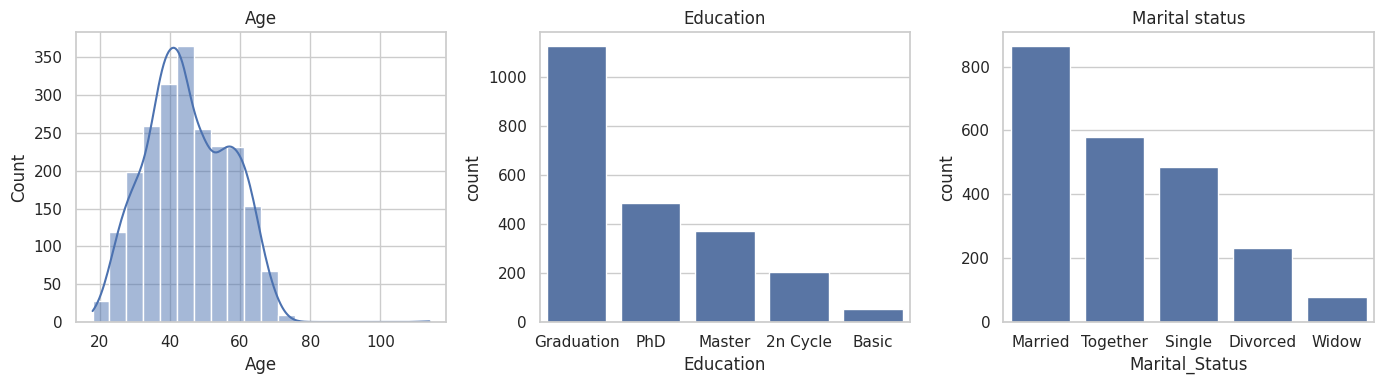

In [ ]:
#Descriptive stats and plots
print(df["Age"].describe().round(2), "\n")
print((df["Education"].value_counts(normalize=True) * 100).round(1).astype(str) + "%", "\n")
print((df["Marital_Status"].value_counts(normalize=True) * 100).round(1).astype(str) + "%")

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(df["Age"], bins=20, kde=True, ax=axs[0]); axs[0].set_title("Age")
sns.countplot(data=df, x="Education", order=df["Education"].value_counts().index, ax=axs[1]); axs[1].set_title("Education")
sns.countplot(data=df, x="Marital_Status", order=df["Marital_Status"].value_counts().index, ax=axs[2]); axs[2].set_title("Marital status")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/demographics.png", dpi=150); plt.show()

##Task 2 - Descriptive Statistics 📊

- **Calculate measures of central tendency (mean, median, mode) and measures of dispersion (variance, standard deviation) for key variables. Identify and handle outliers if necessary.**


**Deliverables**:

- **Descriptive statistics that reveal the central tendencies, variations, and potential outliers in the dataset.**:

  

In [ ]:
d = df[num_cols]
desc = pd.DataFrame({
    "Mean": d.mean(), "Median": d.median(), "Mode": d.mode().iloc[0],
    "Variance": d.var(), "Std Dev": d.std(),          # sample statistics (n-1)
    "Min": d.min(), "Q1": d.quantile(.25), "Q3": d.quantile(.75), "Max": d.max(),
    "Skewness": d.skew()}).round(2)
print(desc.to_string())

desc.to_csv(f"{OUT_DIR}/descriptive_statistics.csv")

                         Mean   Median    Mode      Variance   Std Dev     Min       Q1       Q3       Max  Skewness
Income               51950.08  51412.0  7500.0  4.584088e+08  21410.48  1730.0  35523.0  68274.0  162397.0      0.35
Age                     45.13     44.0    38.0  1.390300e+02     11.79    18.0     37.0     55.0     114.0      0.17
Recency                 49.14     49.0    56.0  8.392600e+02     28.97     0.0     24.0     74.0      99.0     -0.00
Kidhome                  0.44      0.0     0.0  2.900000e-01      0.54     0.0      0.0      1.0       2.0      0.64
Teenhome                 0.51      0.0     0.0  3.000000e-01      0.54     0.0      0.0      1.0       2.0      0.41
MntFishProducts         37.52     12.0     0.0  2.985550e+03     54.64     0.0      3.0     50.0     259.0      1.92
MntMeatProducts        166.91     67.0     7.0  5.092433e+04    225.66     0.0     16.0    232.0    1725.0      2.09
MntFruits               26.27      8.0     0.0  1.577470e+03    

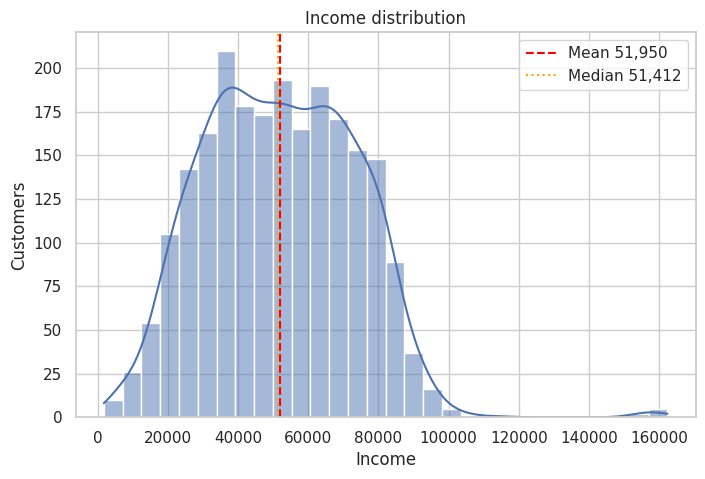

In [ ]:

plt.figure(figsize=(8, 5))
sns.histplot(df["Income"], bins=30, kde=True)
plt.axvline(df["Income"].mean(), color="red", linestyle="--", label=f"Mean {df['Income'].mean():,.0f}")
plt.axvline(df["Income"].median(), color="orange", linestyle=":", label=f"Median {df['Income'].median():,.0f}")
plt.title("Income distribution")
plt.xlabel("Income")
plt.ylabel("Customers")
plt.legend()
plt.show()

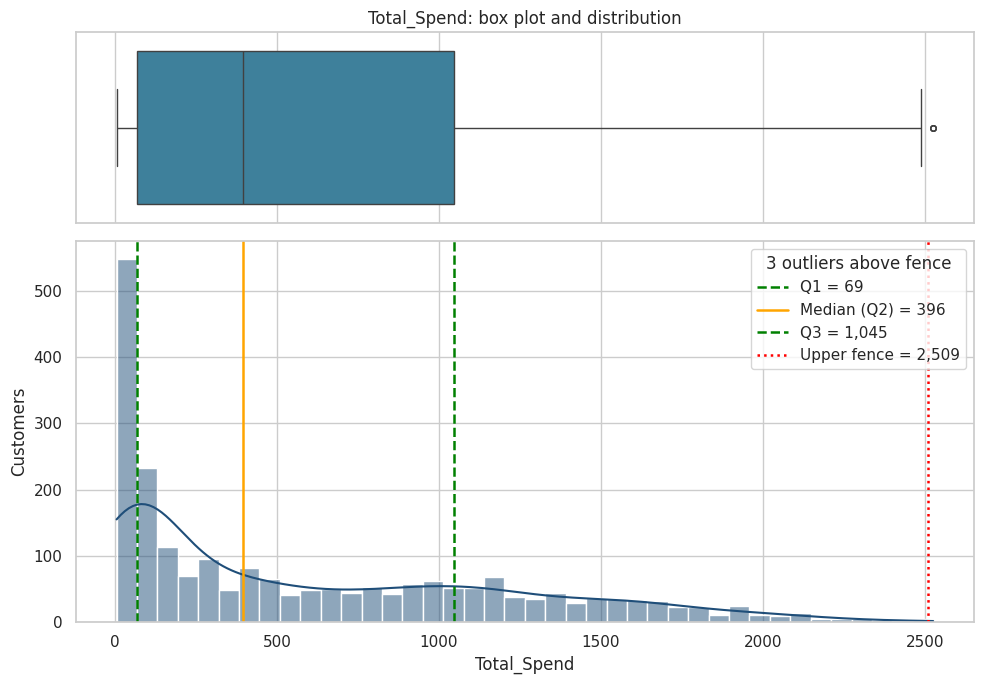

In [ ]:
col = "Total_Spend"
s = df[col].dropna()

q1, med, q3 = s.quantile(0.25), s.median(), s.quantile(0.75)
iqr = q3 - q1
low_f, up_f = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_out = int((s > up_f).sum() + (s < low_f).sum())

fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True,gridspec_kw={"height_ratios": [1, 2]})

# Top: standard box plot
sns.boxplot(x=s, ax=axs[0], color="#2E86AB", flierprops={"marker": "o", "markersize": 4})
axs[0].set_title(f"{col}: box plot and distribution")
axs[0].set_xlabel("")

# Bottom: histogram with the key values marked
sns.histplot(s, bins=40, kde=True, color="#1F4E79", ax=axs[1])
for val, name, colr, ls in [(q1, "Q1", "green", "--"), (med, "Median (Q2)", "orange", "-"),
                            (q3, "Q3", "green", "--"), (up_f, "Upper fence", "red", ":")]:
    axs[1].axvline(val, color=colr, linestyle=ls, linewidth=1.8, label=f"{name} = {val:,.0f}")
axs[1].legend(title=f"{n_out} outliers above fence")
axs[1].set_xlabel(col)
axs[1].set_ylabel("Customers")

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

# Convert to long format: one row per customer per category
long_df = df.melt(id_vars="ID", value_vars=mnt_cols,
                  var_name="Category", value_name="Amount")
long_df["Category"] = long_df["Category"].str.replace("Mnt", "", regex=False)

fig = px.box(long_df, x="Category", y="Amount", color="Category",
             points="outliers", hover_data=["ID"],
             title="Spend by Category")
fig.update_layout(showlegend=False, xaxis_tickangle=-45, height=500)
fig.show()

## Task 3 - Probability Distributions 🎲

- **Identify variables that could follow specific probability distributions (e.g., Binomial, Normal). Calculate probabilities and expected values based on these distributions.**



**Deliverables**:

- **Determination of suitable probability distributions for relevant variables and corresponding calculated probabilities and expected values.**:

  

Response (n=2237): observed acceptances = 334
E[X] = 334.0   Var = 284.1   SD = 16.86
95% range of acceptances: 301 to 367
P(X>=350) = 0.179   P(X>=370) = 0.019

Complain (n=2237): observed complaints = 21
E[X] = 21.0   SD = 4.56   95% range: 13 to 30
P(X>=30) = 0.037


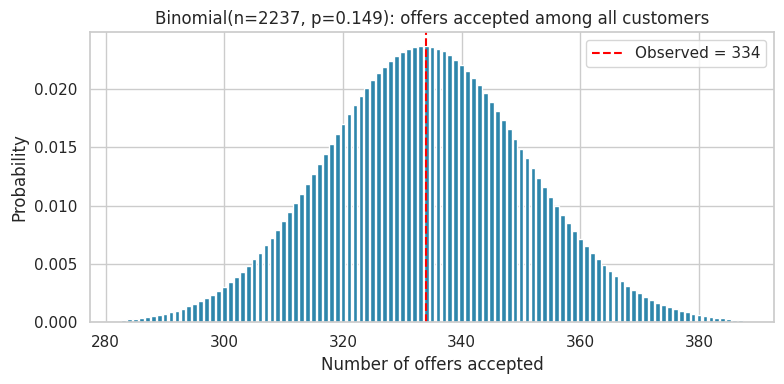

In [ ]:
# Binomial distribution on the whole dataset
summary = []   # one row per variable, collected for the final table

N = len(df)                                   # 2,236 customers
p = df["Response"].mean()                     # acceptance rate
b = stats.binom(N, p)

print(f"Response (n={N}): observed acceptances = {df['Response'].sum()}")
print(f"E[X] = {b.mean():.1f}   Var = {b.var():.1f}   SD = {b.std():.2f}")
lo, hi = b.interval(0.95)
print(f"95% range of acceptances: {lo:.0f} to {hi:.0f}")
print(f"P(X>=350) = {1 - b.cdf(349):.3f}   P(X>=370) = {1 - b.cdf(369):.3f}\n")  #CDF ,Probability of k or fewer

p_c = df["Complain"].mean()
bc = stats.binom(N, p_c)
print(f"Complain (n={N}): observed complaints = {df['Complain'].sum()}")
lo_c, hi_c = bc.interval(0.95)
print(f"E[X] = {bc.mean():.1f}   SD = {bc.std():.2f}   95% range: {lo_c:.0f} to {hi_c:.0f}")
print(f"P(X>=30) = {1 - bc.cdf(29):.3f}")

k = np.arange(int(b.ppf(0.001)), int(b.ppf(0.999)) + 1)   # sensible x-range around the mean
plt.figure(figsize=(8, 4))
plt.bar(k, b.pmf(k), color="#2E86AB")
plt.axvline(df["Response"].sum(), color="red", linestyle="--", label=f"Observed = {df['Response'].sum()}")
plt.title(f"Binomial(n={N}, p={p:.3f}): offers accepted among all customers")
plt.xlabel("Number of offers accepted"); plt.ylabel("Probability")
plt.legend(); plt.tight_layout(); plt.show()

summary.append(["Response", "Binomial", f"p={p:.3f}", f"{N*p:.1f} (n={N})", "Suitable (yes/no outcome)"])
summary.append(["Complain", "Binomial", f"p={p_c:.4f}", f"{N*p_c:.1f} (n={N})", "Suitable (yes/no outcome)"])

Age: mean = 45.1 | sd = 11.8 | skew = 0.17 | excess kurtosis = -0.34 | Shapiro W = 0.982 (p = 4.3e-16) 

Income: mean = 51950.1 | sd = 21410.5 | skew = 0.35 | excess kurtosis = 0.76 | Shapiro W = 0.976 (p = 6.1e-19) 

Total_Spend: mean = 605.7 | sd = 601.8 | skew = 0.86 | excess kurtosis = -0.34 | Shapiro W = 0.865 (p = 3.1e-40) 



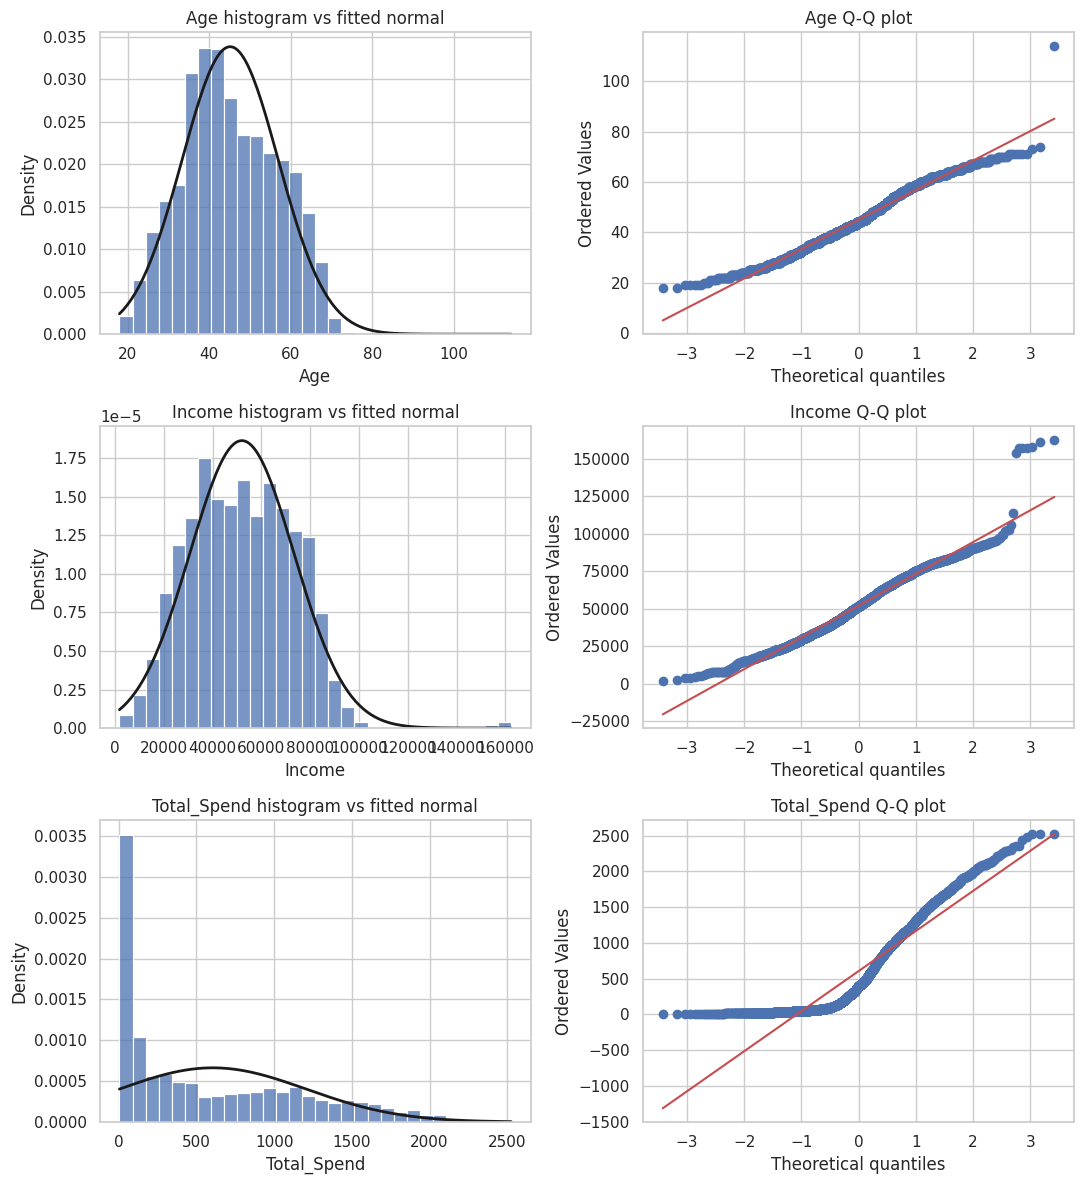

In [ ]:
#Normal Distribution
#Continuous vairable (Age, Income) and non-normal one (Total_Spend)
#Q-Q plot (points on the line = Normal)
normal_vars = ["Age", "Income", "Total_Spend"]
fig, axs =plt.subplots(len(normal_vars), 2, figsize=(11, 4*len(normal_vars)))

for i, v in enumerate(normal_vars):
    x = df[v].dropna()
    sns.histplot(x, bins= 30 , stat= "density", ax =axs[i, 0])
    grid =np.linspace(x.min(), x.max(), 200)
    axs[i, 0].plot(grid, stats.norm.pdf(grid, x.mean(), x.std()), "k", lw=2)
    axs[i, 0].set_title(f"{v} histogram vs fitted normal")

    stats.probplot(x , dist= "norm", plot= axs[i, 1]); axs[i, 1].set_title(f"{v} Q-Q plot")
    W, pv = stats.shapiro(x)
    print(f"{v}: mean = {x.mean():.1f} | sd = {x.std():.1f} | skew = {x.skew():.2f} | "
      f"excess kurtosis = {x.kurt():.2f} | Shapiro W = {W:.3f} (p = {pv:.1e})","\n")

plt.tight_layout(); plt.savefig(f"{OUT_DIR}/t3_normal_distributions.png", dpi=150); plt.show()




In [ ]:
#Probabilty and Expected value under Normal Model
m, s =df["Age"].mean(), df['Age'].std()
print(f"\n Age: E[x]={m:.1f} P(30<=Age<=50) model{stats.norm.cdf(50, m, s) - stats.norm.cdf(30, m, s):.3f}"
      f" vs Obsereved {((df['Age']>=30) & (df['Age']<=50)).mean():.3f}| P(Age>60) model {1-stats.norm.cdf(60,m,s):.3f}"
      f" vs Observed {(df["Age"]>60).mean():.3f}","\n")

m, s =df["Income"].mean(), df['Income'].std()
print(f"Income: E[X]={m:,.0f}  P(Income>70,000) model {1 - stats.norm.cdf(70000, m, s):.3f} "
      f"vs observed {(df['Income'] > 70000).mean():.3f}  |  90th percentile (Normal) {stats.norm.ppf(0.9, m, s):,.0f}")
summary.append(["Age", "Normal", f"mean={df['Age'].mean():.1f}, sd={df['Age'].std():.1f}",
                f"{df['Age'].mean():.1f}", "Good approximation (symmetric)"])
summary.append(["Income", "Normal (approx.)", f"mean={m:,.0f}, sd={s:,.0f}", f"{m:,.0f}",
                "Approximate (slightly right-skewed)"])


 Age: E[x]=45.1 P(30<=Age<=50) model0.560 vs Obsereved 0.570| P(Age>60) model 0.104 vs Observed 0.119 

Income: E[X]=51,950  P(Income>70,000) model 0.200 vs observed 0.226  |  90th percentile (Normal) 79,389


Income: skewness 0.35 -> -0.03, excess kurtosis 0.05 after Box-Cox (lambda=0.72)
Total_Spend: skewness 0.86 -> -0.12, excess kurtosis -1.36 after Box-Cox (lambda=0.18)


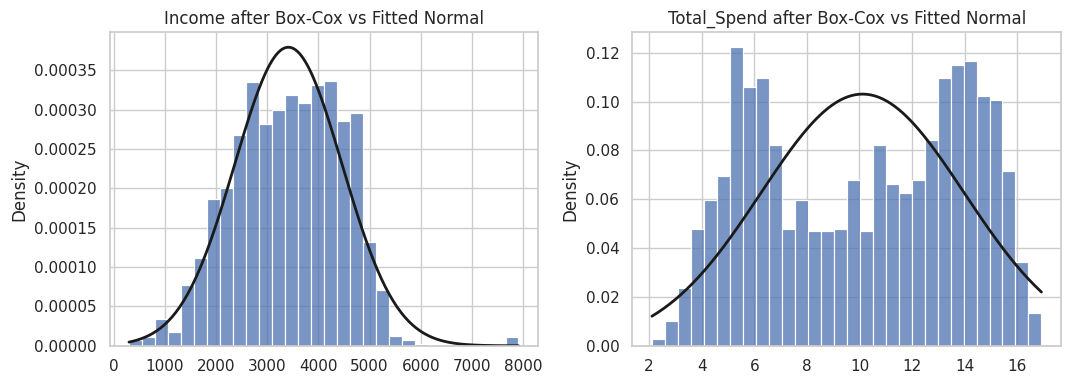

In [ ]:
#Fixing a skewed variable: Box-Cox Transformation
#Box-Cox finds the power transform that makes the data closest to normal.
bc, lam= {}, {}
for v in ["Income", "Total_Spend"]:
    bc[v], lam[v] = stats.boxcox(df[v]+1)
    print(f"{v}: skewness {df[v].skew():.2f} -> {pd.Series(bc[v]).skew():.2f}, "
      f"excess kurtosis {pd.Series(bc[v]).kurt():.2f} after Box-Cox (lambda={lam[v]:.2f})")


fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax , v in zip(axs, bc):
  y= pd.Series(bc[v])
  sns.histplot(y, bins=30, stat="density", ax=ax)
  grid = np.linspace(y.min(), y.max(), 200)
  ax.plot(grid, stats.norm.pdf(grid, y.mean(), y.std()), "k", lw=2)
  ax.set_title(f"{v} after Box-Cox vs Fitted Normal")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/t3_boxcox.png", dpi=150); plt.show()



In [ ]:
#Probability on the transformed scale: transform the threshold with same lambda
from scipy.special import boxcox as boxcox_value
def p_above_boxcox(v, threshold):
  y= pd.Series(bc[v])
  z= (boxcox_value(threshold+1, lam[v]) - y.mean()) / y.std()
  return 1 - stats.norm.cdf(z)

for v, t in [("Income", 70000),("Total_Spend",1000)]:
  raw = 1-stats.norm.cdf(t, df[v].mean(), df[v].std())
  print(f"P{v}>{t: ,}):raw Normal {raw:.3f}| Box-Cox Normal {p_above_boxcox(v,t):.3f}"
        f"| observed {((df[v]>t).mean()):.3f}")
  summary.append(["Total_Spend", "Not Normal; Normal after Box-Cox", f"lambda={lam["Total_Spend"]:.2f}",
                  f"{df['Total_Spend'].mean():.0f}(raw mean)","Two customer groups: Normal not suitable"])
#


PIncome> 70,000):raw Normal 0.200| Box-Cox Normal 0.196| observed 0.226
PTotal_Spend> 1,000):raw Normal 0.256| Box-Cox Normal 0.190| observed 0.269


NumWebPurchases: E[X]=4.09 var=7.73 dispersion=1.89 | P(X=0) model 0.017 vs observed 0.022 | P(X>=5) model 0.388 vs observed 0.379 

NumDealsPurchases: E[X]=2.33 var=3.74 dispersion=1.61 | P(X=0) model 0.098 vs observed 0.021 | P(X>=5) model 0.087 vs observed 0.108 

NumCatalogPurchases: E[X]=2.66 var=8.55 dispersion=3.21 | P(X=0) model 0.070 vs observed 0.262 | P(X>=5) model 0.132 vs observed 0.230 

NumStorePurchases: E[X]=5.79 var=10.57 dispersion=1.82 | P(X=0) model 0.003 vs observed 0.007 | P(X>=5) model 0.686 vs observed 0.528 

NumWebVisitsMonth: E[X]=5.32 var=5.89 dispersion=1.11 | P(X=0) model 0.005 vs observed 0.005 | P(X>=5) model 0.614 vs observed 0.648 



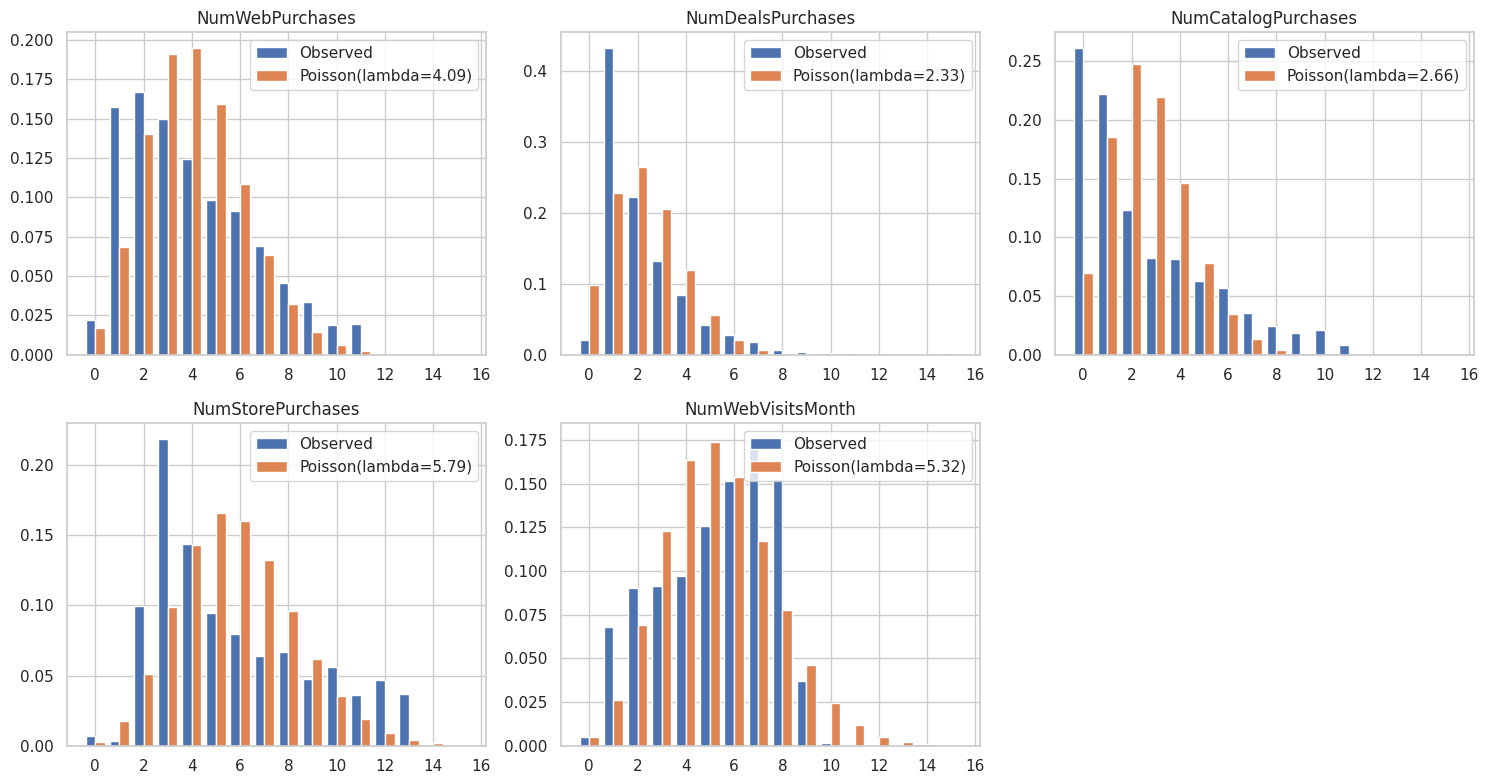

In [ ]:
#Possion: count of events(purchase)
#possion assume mean= variance. Dispersion ration= variance/ mean
count_vars = ["NumWebPurchases", "NumDealsPurchases", "NumCatalogPurchases",
              "NumStorePurchases", "NumWebVisitsMonth"]

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()
for ax, c in zip(axs, count_vars):
    lam_c = df[c].mean()
    disp = df[c].var() / lam_c
    po_model, po_obs = stats.poisson.pmf(0, lam_c), (df[c] == 0).mean()
    print(f"{c}: E[X]={lam_c:.2f} var={df[c].var():.2f} dispersion={disp:.2f} | "
          f"P(X=0) model {po_model:.3f} vs observed {po_obs:.3f} | "
          f"P(X>=5) model {1 - stats.poisson.cdf(4, lam_c):.3f} vs observed {(df[c] >= 5).mean():.3f}","\n")

    ks = np.arange(0, 16)
    obs = df[c].value_counts(normalize=True).reindex(ks, fill_value=0)
    ax.bar(ks - 0.2, obs.values, 0.4, label="Observed")
    ax.bar(ks + 0.2, stats.poisson.pmf(ks, lam_c), 0.4, label=f"Poisson(lambda={lam_c:.2f})")
    ax.set_title(c); ax.legend()

    if abs(po_model - po_obs) > 0.05 or disp > 2:
        verdict = "Poor fit (strongly over-dispersed / wrong share of zeros)"
    elif disp > 1.25:
        verdict = "Rough fit (over-dispersed)"
    else:
        verdict = "Good fit (mean is close to variance)"
    summary.append([c, "Poisson", f"lambda={lam_c:.2f}", f"{lam_c:.2f}", verdict])

axs[-1].axis("off")          # hides the unused sixth panel
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/t3_poisson_all.png", dpi=150); plt.show()

In [ ]:
#Uniform : Recency(days since last purchase)
a,b_= 0, 99
ks_p= stats.kstest(df["Recency"], "uniform", args=(a, b_ -a)).pvalue
print(f"Recency: E[x]= (a+b)/2 ={(a+ b_)/2:.1f} (sample mean){df["Recency"].mean():.1f})|"
      f"P(Rececny<=30) model {stats.uniform.cdf(30, a,b_ -a):.3f} vs observed {(df["Recency"]<=30).mean():.3f}| KS p={ks_p:.2f}","\n")
summary.append(["Recency", "Uniform(0,99)", f"a={a}, b={b_}", f"{(a + b_) / 2:.1f}", "Constent with uniform(KS p=%.2f)"%ks_p])

#Summary: Sutable for each distribution
task3_table = pd.DataFrame(summary, columns=["Variable", "Distribution", "Parameters", "Expected value", "Verdict"])

# Styled table: dark header, left-aligned text, long verdicts wrap onto a second line
styled = (task3_table.style
          .hide(axis="index")
          .set_properties(**{"text-align": "left", "white-space": "normal",
                             "font-size": "14px", "padding": "6px 12px"})
          .set_table_styles([{"selector": "th",
                              "props": [("background-color", "#1F4E79"), ("color", "white"),
                                        ("text-align", "left"), ("font-size", "14px"),
                                        ("padding", "6px 12px")]}]))
display(styled)

task3_table.to_csv(f"{OUT_DIR}/task3_distribution_summary.csv", index=False)

Recency: E[x]= (a+b)/2 =49.5 (sample mean)49.1)|P(Rececny<=30) model 0.303 vs observed 0.323| KS p=0.31 



Variable,Distribution,Parameters,Expected value,Verdict
Response,Binomial,p=0.149,334.0 (n=2237),Suitable (yes/no outcome)
Complain,Binomial,p=0.0094,21.0 (n=2237),Suitable (yes/no outcome)
Age,Normal,"mean=45.1, sd=11.8",45.1,Good approximation (symmetric)
Income,Normal (approx.),"mean=51,950, sd=21,410","51,950",Approximate (slightly right-skewed)
Total_Spend,Not Normal; Normal after Box-Cox,lambda=0.18,606(raw mean),Two customer groups: Normal not suitable
Total_Spend,Not Normal; Normal after Box-Cox,lambda=0.18,606(raw mean),Two customer groups: Normal not suitable
NumWebPurchases,Poisson,lambda=4.09,4.09,Rough fit (over-dispersed)
NumDealsPurchases,Poisson,lambda=2.33,2.33,Poor fit (strongly over-dispersed / wrong share of zeros)
NumCatalogPurchases,Poisson,lambda=2.66,2.66,Poor fit (strongly over-dispersed / wrong share of zeros)
NumStorePurchases,Poisson,lambda=5.79,5.79,Rough fit (over-dispersed)


## Task 4: Insights and Customer Segmentation 📈

- **Explore relationships between customer characteristics and spending habits. Segment customers based on their behaviors and characteristics.**

**Deliverables**:

- **Key insights regarding relationships between variables and distinct customer segments based on behaviors.**

  

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2237 non-null   int64         
 1   Year_Birth           2237 non-null   int64         
 2   Education            2237 non-null   object        
 3   Marital_Status       2237 non-null   object        
 4   Income               2237 non-null   float64       
 5   Kidhome              2237 non-null   int64         
 6   Teenhome             2237 non-null   int64         
 7   Dt_Customer          1322 non-null   datetime64[ns]
 8   Recency              2237 non-null   int64         
 9   MntWines             2237 non-null   int64         
 10  MntFruits            2237 non-null   int64         
 11  MntMeatProducts      2237 non-null   int64         
 12  MntFishProducts      2237 non-null   int64         
 13  MntSweetProducts     2237 non-nul

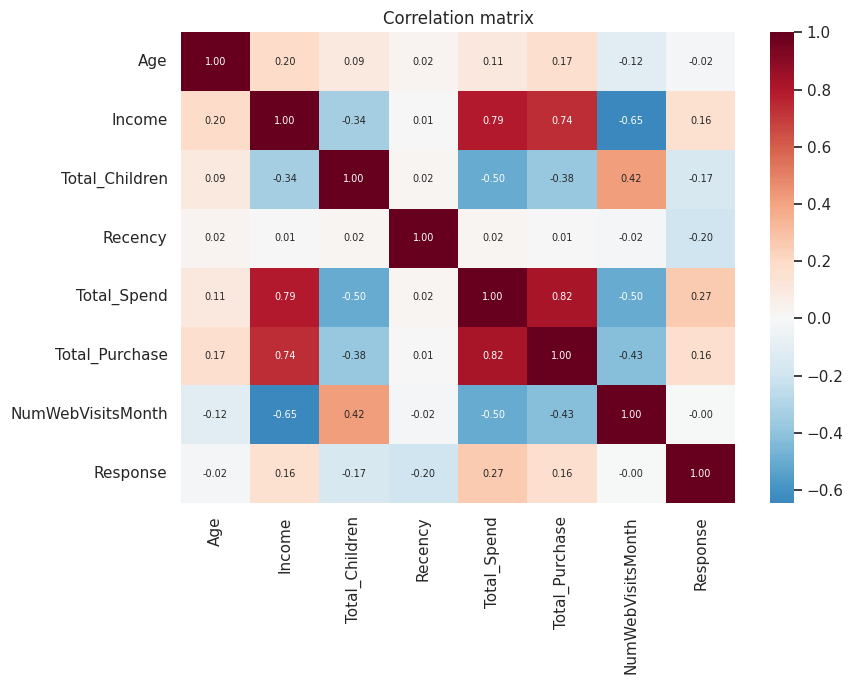

Income: accepted mean=60181.9, not accepted=50505.3, p=3.80e-12 

Total_Spend: accepted mean=987.4, not accepted=538.8, p=2.90e-24 

Recency: accepted mean=35.4, not accepted=51.6, p=9.07e-21 

Age: accepted mean=44.6, not accepted=45.2, p=3.77e-01 

Chi-square Education vs Response: p = 1.21e-04 

Chi-square Marital_Status vs Response: p = 1.75e-10 

Education
2n Cycle      0.109
Basic         0.037
Graduation    0.135
Master        0.154
PhD           0.208
Name: Response, dtype: float64 

Marital_Status
Divorced    0.207
Married     0.113
Single      0.224
Together    0.104
Widow       0.247
Name: Response, dtype: float64 



In [ ]:
corr_cols = ["Age", "Income", "Total_Children", "Recency", "Total_Spend", "Total_Purchase", "NumWebVisitsMonth", "Response"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, annot_kws={"size": 7})
plt.title("Correlation matrix"); plt.tight_layout(); plt.savefig(f"{OUT_DIR}/correlation.png", dpi=150); plt.show()

acc, rej = df[df["Response"] == 1], df[df["Response"] == 0]
for col in ["Income", "Total_Spend", "Recency", "Age"]:
    t = stats.ttest_ind(acc[col], rej[col], equal_var=False)
    print(f"{col}: accepted mean={acc[col].mean():.1f}, not accepted={rej[col].mean():.1f}, p={t.pvalue:.2e}","\n")
for col in ["Education", "Marital_Status"]:
    print(f"Chi-square {col} vs Response: p = {stats.chi2_contingency(pd.crosstab(df[col], df['Response']))[1]:.2e}","\n")
print(df.groupby("Education")["Response"].mean().round(3), "\n")
print(df.groupby("Marital_Status")["Response"].mean().round(3),"\n")

In [ ]:
# %% 4.2 Segmentation with k-means
features = ["Income", "Total_Spend", "Recency", "Total_Children",
            "Total_Purchase", "NumWebVisitsMonth", "Age"]
X = StandardScaler().fit_transform(df[features])

for k in range(2, 7):
    km = KMeans(k, n_init=10, random_state=42).fit(X)
    print(f"k={k}  inertia={km.inertia_:.0f}  silhouette={silhouette_score(X, km.labels_):.3f}")

km = KMeans(4, n_init=10, random_state=42).fit(X)
df["Cluster"] = km.labels_

# Profile: the 7 clustering features, plus deals and acceptance for description
profile = df.groupby("Cluster").agg(
    N=("ID", "count"), Income=("Income", "mean"), Spend=("Total_Spend", "mean"),
    Children=("Total_Children", "mean"), Purchases=("Total_Purchase", "mean"),
    WebVisits=("NumWebVisitsMonth", "mean"), Recency=("Recency", "mean"), Age=("Age", "mean"),
    Deals=("NumDealsPurchases", "mean"), Acceptance=("Response", "mean")).round(2)
print(profile.to_string(),"\n")

names = {}
names[profile["Spend"].idxmax()] = "Big Spenders"
rest = profile.drop(index=list(names))
names[rest["Age"].idxmin()] = "Young Budget Shoppers"
rest = rest.drop(index=[rest["Age"].idxmin()])
names[rest["Spend"].idxmax()] = "Mid-Value Families"
names[rest["Spend"].idxmin()] = "Low-Spend Families"
df["Segment"] = df["Cluster"].map(names)
seg_summary = (df.groupby("Segment")["Response"]
               .agg(Customers="count", Acceptance_pct=lambda s: (s.mean() * 100).round(1))
               .sort_values("Acceptance_pct", ascending=False))
print(seg_summary)


k=2  inertia=9888  silhouette=0.327
k=3  inertia=8715  silhouette=0.225
k=4  inertia=7725  silhouette=0.200
k=5  inertia=7165  silhouette=0.189
k=6  inertia=6622  silhouette=0.187
           N    Income    Spend  Children  Purchases  WebVisits  Recency    Age  Deals  Acceptance
Cluster                                                                                           
0        656  30809.91   122.04      0.81       6.35       6.88    47.99  36.96   1.98        0.12
1        598  61529.91   863.84      1.03      18.46       5.34    48.92  50.00   3.22        0.13
2        490  78404.74  1399.51      0.08      19.09       2.33    49.75  44.89   1.07        0.28
3        493  42165.95   147.38      1.91       7.11       6.19    50.33  50.35   2.95        0.08 

                       Customers  Acceptance_pct
Segment                                         
Big Spenders                 490            28.4
Mid-Value Families           598            12.9
Young Budget Shoppers       

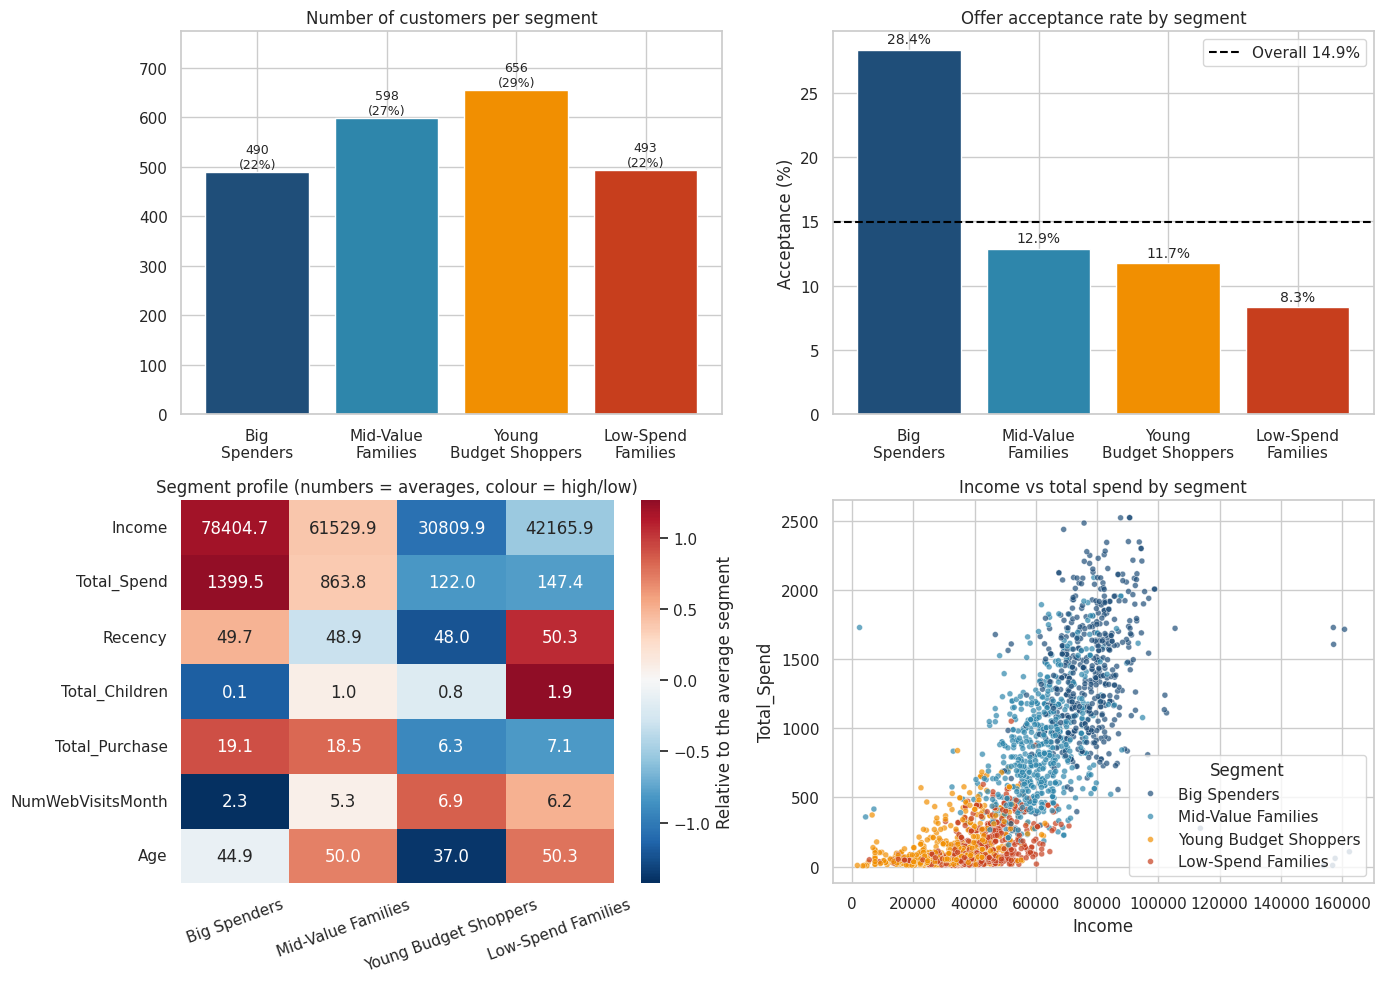

In [ ]:
order = ["Big Spenders", "Mid-Value Families", "Young Budget Shoppers", "Low-Spend Families"]
colors = dict(zip(order, ["#1F4E79", "#2E86AB", "#F18F01", "#C73E1D"]))
overall = df["Response"].mean() * 100
labels = [s.replace(" ", "\n", 1) for s in order]   # two-line labels so they do not overlap

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1. Segment sizes
sizes = df["Segment"].value_counts().reindex(order)
axs[0, 0].bar(labels, sizes.values, color=[colors[s] for s in order])
for i, v in enumerate(sizes.values):
    axs[0, 0].text(i, v + 8, f"{v}\n({v / len(df):.0%})", ha="center", fontsize=9)
axs[0, 0].set_title("Number of customers per segment"); axs[0, 0].set_ylim(0, sizes.max() * 1.18)

# 2. Offer acceptance rate
rate = df.groupby("Segment")["Response"].mean().reindex(order) * 100
axs[0, 1].bar(labels, rate.values, color=[colors[s] for s in order])
axs[0, 1].axhline(overall, color="black", linestyle="--", label=f"Overall {overall:.1f}%")
for i, v in enumerate(rate.values):
    axs[0, 1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)
axs[0, 1].set_title("Offer acceptance rate by segment"); axs[0, 1].set_ylabel("Acceptance (%)"); axs[0, 1].legend()

# 3. Profile heatmap (each feature standardised so different units can be compared)
prof = df.groupby("Segment")[features].mean().reindex(order)
z = (prof - prof.mean()) / prof.std()
sns.heatmap(z.T, annot=prof.T.round(1), fmt="", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Relative to the average segment"}, ax=axs[1, 0])
axs[1, 0].set_title("Segment profile (numbers = averages, colour = high/low)"); axs[1, 0].set_xlabel("")
axs[1, 0].tick_params(axis="x", rotation=20)

# 4. Income vs total spend
sns.scatterplot(data=df, x="Income", y="Total_Spend", hue="Segment", hue_order=order,
                palette=colors, s=18, alpha=0.7, ax=axs[1, 1])
axs[1, 1].set_title("Income vs total spend by segment")

plt.tight_layout(); plt.savefig(f"{OUT_DIR}/segments_overview.png", dpi=150); plt.show()

## Task 5: Conclusion and Recommendations

- **Create clear visualizations to showcase your findings. Use insights to make recommendations for the company based on your analysis.**

**Deliverables**:

- **Well-designed visualizations that visually represent your insights and actionable recommendations based on customer behavior analysis.**

/tmp/ipykernel_455/853024312.py:19: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_455/853024312.py:19: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



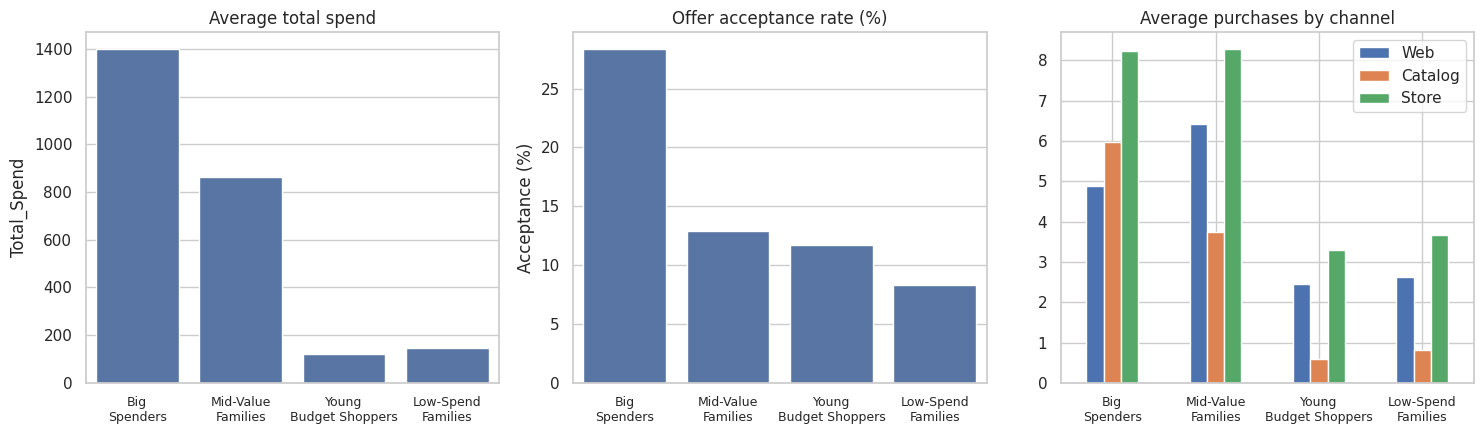

In [ ]:
order = ["Big Spenders", "Mid-Value Families", "Young Budget Shoppers", "Low-Spend Families"]

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

sns.barplot(data=df, x="Segment", y="Total_Spend", order=order, errorbar=None, ax=axs[0])
axs[0].set_title("Average total spend")

df["Acceptance (%)"] = df["Response"] * 100
sns.barplot(data=df, x="Segment", y="Acceptance (%)", order=order, errorbar=None, ax=axs[1])
axs[1].set_title("Offer acceptance rate (%)")

channels = df.groupby("Segment")[["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]].mean().loc[order]
channels.columns = ["Web", "Catalog", "Store"]
channels.plot(kind="bar", ax=axs[2])
axs[2].set_title("Average purchases by channel")

for a in axs:
    a.set_xlabel("")
    a.set_xticklabels([t.get_text().replace(" ", "\n", 1) for t in a.get_xticklabels()], rotation=0, fontsize=9)

plt.tight_layout(); plt.savefig(f"{OUT_DIR}/segments.png", dpi=150); plt.show()

## Bonus Task - Geogebra Experiment



Here's the link to an intriguing GeoGebra experiment: [GeoGebra Experiment Link](https://www.geogebra.org/m/LZbwMZtJ)

This experiment lets you simulate coin flips as per your preferences and specifications!

Your task involves recording a video where you'll explain the concept of the **Law of Large Numbers** using this experiment. Dive further into the experience by adjusting the number of coins and exploring varying coin biases. 🪙📹🔍